In [1]:
# %%
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# %%
EMBEDDINGS_DIR = Path("embeddings")

GOLDEN_LABEL = "Qwen3-Embedding-0.6B-f16.gguf"
GOLDEN_PATH = EMBEDDINGS_DIR / f"{GOLDEN_LABEL}.json"

OUTPUT_DIR = Path("outputs_topk_neighbor_overlap")
OUTPUT_DIR.mkdir(exist_ok=True)

assert EMBEDDINGS_DIR.exists(), f"Directory not found: {EMBEDDINGS_DIR.resolve()}"
assert GOLDEN_PATH.exists(), f"Golden file not found: {GOLDEN_PATH.resolve()}"

json_paths = sorted(EMBEDDINGS_DIR.glob("*.json"))

print("Found files:")
for path in json_paths:
    print("-", path.name)

Found files:
- Qwen3-Embedding-0.6B-Q8_0.gguf.json
- Qwen3-Embedding-0.6B-f16.gguf.json
- Qwen3-Embedding-0.6B.i1-Q2_K.gguf.json
- Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf.json
- Qwen3-Embedding-0.6B.i1-Q6_K.gguf.json


In [3]:
# %%
def load_embedding_json(path: Path) -> dict:
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def flatten_embedding_file(path: Path) -> pd.DataFrame:
    data = load_embedding_json(path)
    label = path.stem

    rows = []

    groups = data.get("groups")
    if not isinstance(groups, dict):
        raise ValueError(f"Invalid JSON format: groups not found in {path}")

    for group_name, group_data in groups.items():
        items = group_data.get("items")
        if not isinstance(items, list):
            raise ValueError(f"Invalid JSON format: groups.{group_name}.items not found in {path}")

        for item in items:
            embedding = item.get("embedding")
            if embedding is None:
                raise ValueError(f"Embedding missing: {path}, group={group_name}, item={item}")

            rows.append({
                "label": label,
                "group": group_name,
                "index": int(item["index"]),
                "text": item["text"],
                "dimension": len(embedding),
                "embedding": np.asarray(embedding, dtype=np.float32),
            })

    return pd.DataFrame(rows)


all_df = pd.concat(
    [flatten_embedding_file(path) for path in json_paths],
    ignore_index=True,
)

display(all_df.head())

,label,group,index,text,dimension,embedding
0,Qwen3-Embedding-0.6B-Q8_0.gguf,words,0,회사원,1024,"[-0.0030338056, -0.15160239, -0.011095128, -0...."
1,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1,살해범,1024,"[-0.011650151, -0.01508228, -0.011664755, 0.04..."
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,2,수캐,1024,"[0.01099435, -0.019578675, -0.013508767, 0.023..."
3,Qwen3-Embedding-0.6B-Q8_0.gguf,words,3,퍼덕이다,1024,"[0.016206378, -0.011092099, -0.014384843, -0.0..."
4,Qwen3-Embedding-0.6B-Q8_0.gguf,words,4,마그마,1024,"[-0.010670422, -0.027787939, -0.012867507, -0...."


In [4]:
# %%
def normalize_matrix(x: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(x, axis=1, keepdims=True)
    return x / np.clip(norms, 1e-12, None)


def cosine_similarity_matrix(x: np.ndarray) -> np.ndarray:
    x = normalize_matrix(x)
    return x @ x.T


def topk_indices(sim_matrix: np.ndarray, k: int) -> np.ndarray:
    """
    자기 자신은 제외하고 top-k index를 반환한다.

    샘플 수가 커지면 np.argsort(-sim, axis=1)는 전체 정렬을 수행해서 느릴 수 있다.
    여기서는 argpartition으로 후보 k개를 먼저 뽑고, 그 후보 안에서만 정렬한다.
    """
    if sim_matrix.ndim != 2 or sim_matrix.shape[0] != sim_matrix.shape[1]:
        raise ValueError(f"sim_matrix must be square: shape={sim_matrix.shape}")

    n = sim_matrix.shape[0]
    if not (1 <= k <= n - 1):
        raise ValueError(f"k must satisfy 1 <= k <= n - 1. got k={k}, n={n}")

    sim = sim_matrix.copy()
    np.fill_diagonal(sim, -np.inf)

    # 각 row에서 similarity가 큰 k개 후보를 O(n) 근사 비용으로 추출
    candidate = np.argpartition(-sim, kth=k - 1, axis=1)[:, :k]
    candidate_scores = np.take_along_axis(sim, candidate, axis=1)

    # 후보 k개 안에서는 정확한 내림차순 정렬
    order = np.argsort(-candidate_scores, axis=1)
    return np.take_along_axis(candidate, order, axis=1)


def topk_overlap_per_row(golden_topk: np.ndarray, model_topk: np.ndarray, k: int) -> list[float]:
    scores = []

    for row_a, row_b in zip(golden_topk, model_topk):
        overlap = len(set(row_a[:k]) & set(row_b[:k])) / k
        scores.append(float(overlap))

    return scores


def build_embedding_matrix(df: pd.DataFrame, label: str, group: str):
    target = df[(df["label"] == label) & (df["group"] == group)].copy()
    target = target.sort_values(["group", "index"]).reset_index(drop=True)

    if target.empty:
        return [], [], np.empty((0, 0), dtype=np.float32)

    texts = target["text"].tolist()
    indices = target["index"].tolist()
    embeddings = np.stack(target["embedding"].to_numpy()).astype(np.float32, copy=False)

    return indices, texts, embeddings


def short_model_label(label: str) -> str:
    prefix = "Qwen3-Embedding-0.6B-"
    suffix = ".gguf"

    name = label

    if name.startswith(prefix):
        name = name[len(prefix):]

    if name.endswith(suffix):
        name = name[:-len(suffix)]

    return name


In [5]:
# %%
GROUP_ORDER = ["words", "sentences", "documents"]
GROUP_LABEL_MAP = {
    "words": "words",
    "sentences": "sentences",
    "documents": "documents",
}

# 샘플 수가 늘어난 경우를 전제로 더 큰 k까지 평가한다.
# 각 group의 샘플 수보다 큰 k는 자동으로 제외된다.
TOP_K_CANDIDATES = [1, 5, 10, 20, 50, 100]

# detail row는 커질 수 있으므로 너무 큰 k는 제외한다.
# summary는 TOP_K_CANDIDATES 전체를 계산하고, detail은 아래 k만 저장한다.
DETAIL_K_CANDIDATES = [1, 5, 10]

ranking_rows = []
ranking_detail_rows = []

labels = sorted(label for label in all_df["label"].unique() if label != GOLDEN_LABEL)

for group in GROUP_ORDER:
    golden_indices, golden_texts, golden_emb = build_embedding_matrix(all_df, GOLDEN_LABEL, group)

    if len(golden_texts) == 0:
        print(f"[SKIP] empty baseline group: {group}")
        continue

    max_k = len(golden_texts) - 1
    if max_k < 1:
        print(f"[SKIP] not enough samples: group={group}, count={len(golden_texts)}")
        continue

    k_list = [k for k in TOP_K_CANDIDATES if k <= max_k]
    detail_k_set = {k for k in DETAIL_K_CANDIDATES if k <= max_k}

    print(f"group={group}, count={len(golden_texts)}, k_list={k_list}")

    golden_sim = cosine_similarity_matrix(golden_emb)
    golden_topk_cache = {k: topk_indices(golden_sim, k) for k in k_list}

    for label in labels:
        model_indices, model_texts, model_emb = build_embedding_matrix(all_df, label, group)

        if len(model_texts) == 0:
            print(f"[SKIP] empty model group: label={label}, group={group}")
            continue

        if golden_texts != model_texts:
            raise ValueError(f"text order mismatch: label={label}, group={group}")

        model_sim = cosine_similarity_matrix(model_emb)

        for k in k_list:
            golden_topk = golden_topk_cache[k]
            model_topk = topk_indices(model_sim, k)
            row_scores = topk_overlap_per_row(golden_topk, model_topk, k)

            ranking_rows.append({
                "label": label,
                "group": group,
                "sample_count": len(golden_texts),
                "k": k,
                "topk_overlap_mean": float(np.mean(row_scores)),
                "topk_overlap_min": float(np.min(row_scores)),
                "topk_overlap_p05": float(np.quantile(row_scores, 0.05)),
                "topk_overlap_p50": float(np.quantile(row_scores, 0.50)),
                "topk_overlap_max": float(np.max(row_scores)),
                "count": len(row_scores),
            })

            if k in detail_k_set:
                for row_idx, score in enumerate(row_scores):
                    ranking_detail_rows.append({
                        "label": label,
                        "group": group,
                        "sample_count": len(golden_texts),
                        "k": k,
                        "index": golden_indices[row_idx],
                        "text": golden_texts[row_idx],
                        "topk_overlap": score,
                        # 샘플 수가 커졌으므로 text list 전체는 저장하지 않는다.
                        # 필요한 케이스만 아래 inspect_neighbors 함수로 확인한다.
                        "golden_topk_indices": [golden_indices[i] for i in golden_topk[row_idx].tolist()],
                        "model_topk_indices": [model_indices[i] for i in model_topk[row_idx].tolist()],
                    })


ranking_df = pd.DataFrame(ranking_rows)
ranking_detail_df = pd.DataFrame(ranking_detail_rows)

if ranking_df.empty:
    raise RuntimeError("No ranking rows were generated. Check labels, groups, and embedding files.")

display(ranking_df)


group=words, count=1000, k_list=[1, 5, 10, 20, 50, 100]
group=sentences, count=1000, k_list=[1, 5, 10, 20, 50, 100]
group=documents, count=300, k_list=[1, 5, 10, 20, 50, 100]


,label,group,sample_count,k,topk_overlap_mean,topk_overlap_min,topk_overlap_p05,topk_overlap_p50,topk_overlap_max,count
0,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,1,0.896000,0.00,0.0000,1.00,1.0,1000
1,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,5,0.918400,0.40,0.8000,1.00,1.0,1000
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,10,0.925400,0.70,0.8000,0.90,1.0,1000
3,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,20,0.930150,0.70,0.8500,0.95,1.0,1000
4,Qwen3-Embedding-0.6B-Q8_0.gguf,words,1000,50,0.942440,0.72,0.9000,0.94,1.0,1000
...,...,...,...,...,...,...,...,...,...,...
103,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,300,5,0.933333,0.60,0.8000,1.00,1.0,300
104,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,300,10,0.943333,0.70,0.8000,1.00,1.0,300
105,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,300,20,0.946667,0.80,0.8975,0.95,1.0,300
106,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,300,50,0.960533,0.88,0.9200,0.96,1.0,300


In [6]:
# %%
pivot = (
    ranking_df
    .pivot_table(
        index=["label", "group"],
        columns="k",
        values="topk_overlap_mean",
    )
    .reset_index()
)

display(pivot)

k,label,group,1,5,10,20,50,100
0,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,0.970000,0.968000,0.966000,0.967833,0.979067,0.982733
1,Qwen3-Embedding-0.6B-Q8_0.gguf,sentences,0.974000,0.961400,0.964300,0.967150,0.972340,0.976550
2,Qwen3-Embedding-0.6B-Q8_0.gguf,words,0.896000,0.918400,0.925400,0.930150,0.942440,0.952600
3,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,documents,0.380000,0.500000,0.533333,0.577833,0.655000,0.724967
4,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,sentences,0.413000,0.425000,0.440000,0.457000,0.490520,0.525170
5,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,words,0.213000,0.241200,0.243700,0.260950,0.308880,0.375700
6,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,documents,0.683333,0.706667,0.719000,0.758333,0.808133,0.847633
7,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,sentences,0.626000,0.671600,0.703500,0.724850,0.749400,0.768530
8,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,words,0.400000,0.450200,0.466100,0.484500,0.532620,0.592560
9,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,documents,0.826667,0.824667,0.844000,0.859500,0.892467,0.918533


saved: outputs_topk_neighbor_overlap/top10_neighbor_overlap_words.png


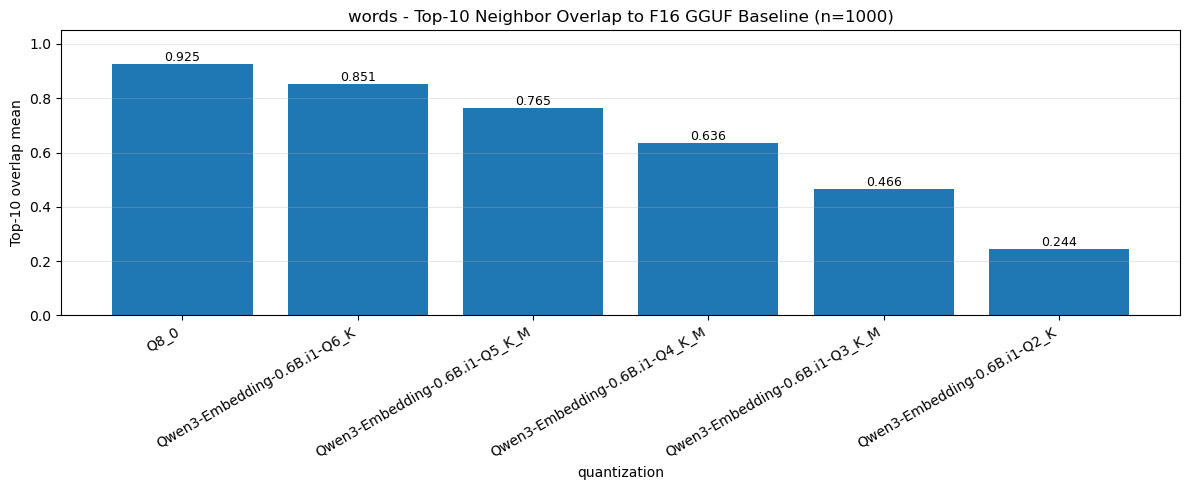

saved: outputs_topk_neighbor_overlap/top10_neighbor_overlap_sentences.png


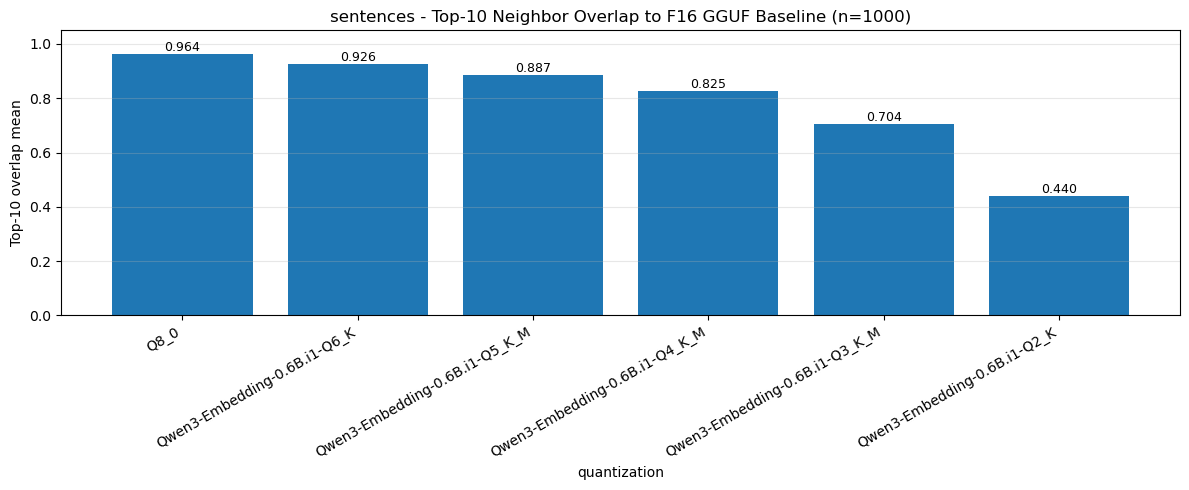

saved: outputs_topk_neighbor_overlap/top10_neighbor_overlap_documents.png


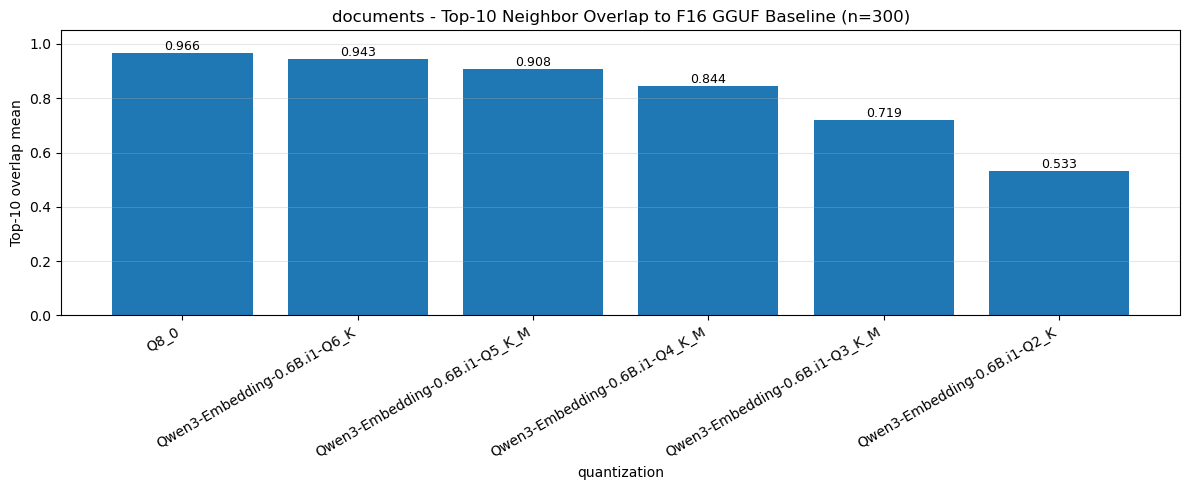

In [7]:
# %%
def plot_topk_overlap_by_group(group_name: str, k: int):
    target = ranking_df[
        (ranking_df["group"] == group_name)
        & (ranking_df["k"] == k)
    ].copy()

    if target.empty:
        print(f"[SKIP] group={group_name}, k={k}")
        return None

    target = target.sort_values("topk_overlap_mean", ascending=False)
    target["display_label"] = target["label"].map(short_model_label)

    fig = plt.figure(figsize=(12, 5))
    ax = plt.gca()

    bars = ax.bar(
        target["display_label"],
        target["topk_overlap_mean"],
    )

    group_display_name = GROUP_LABEL_MAP.get(group_name, group_name)
    sample_count = int(target["sample_count"].iloc[0])

    ax.set_title(f"{group_display_name} - Top-{k} Neighbor Overlap to F16 GGUF Baseline (n={sample_count})")
    ax.set_xlabel("quantization")
    ax.set_ylabel(f"Top-{k} overlap mean")
    ax.set_ylim(0, 1.05)
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, target["topk_overlap_mean"]):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"top{k}_neighbor_overlap_{group_name}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"saved: {output_path}")

    plt.show()

    return target


# 샘플 수가 늘어났으므로 기본 bar chart는 Top-10 기준으로 그린다.
# group 크기가 10보다 작으면 가능한 최대 k로 자동 조정된다.
plot_results = []

for group_name in GROUP_ORDER:
    available_ks = sorted(ranking_df[ranking_df["group"] == group_name]["k"].unique())
    if not available_ks:
        continue

    selected_k = 10 if 10 in available_ks else max(available_ks)
    plot_results.append(plot_topk_overlap_by_group(group_name, int(selected_k)))


saved: outputs_topk_neighbor_overlap/topk_overlap_curve_words.png


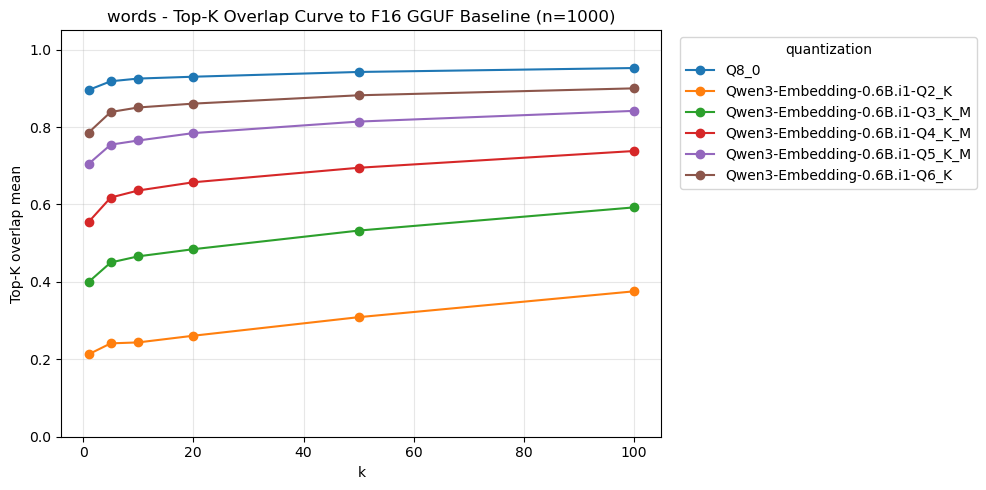

saved: outputs_topk_neighbor_overlap/topk_overlap_curve_sentences.png


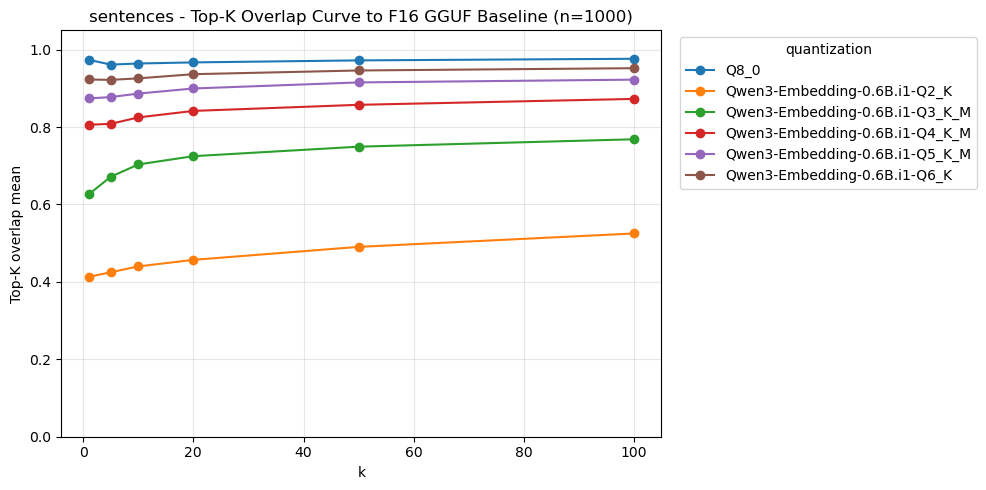

saved: outputs_topk_neighbor_overlap/topk_overlap_curve_documents.png


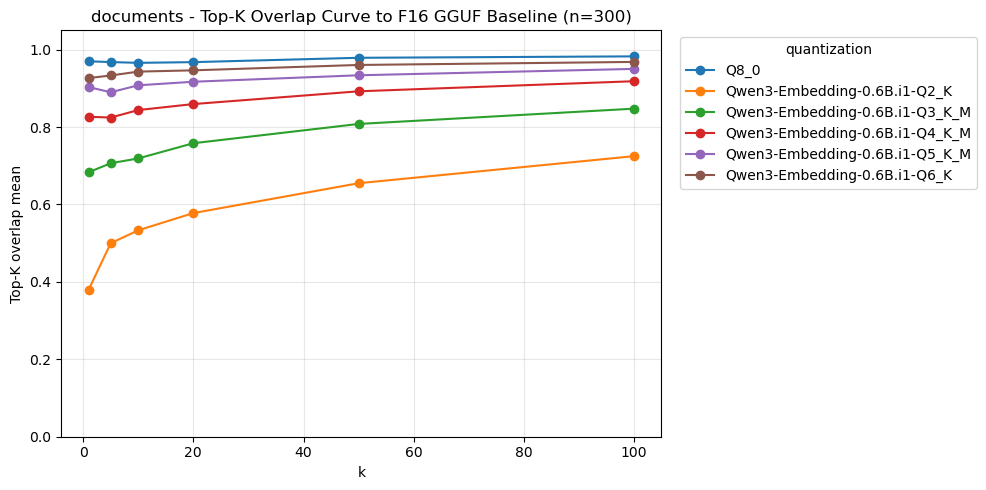

In [8]:
# %%
# k 변화에 따라 overlap이 어떻게 변하는지 group별로 확인한다.

def plot_topk_overlap_curve_by_group(group_name: str):
    target = ranking_df[ranking_df["group"] == group_name].copy()

    if target.empty:
        print(f"[SKIP] group={group_name}")
        return None

    target["display_label"] = target["label"].map(short_model_label)
    group_display_name = GROUP_LABEL_MAP.get(group_name, group_name)
    sample_count = int(target["sample_count"].iloc[0])

    fig = plt.figure(figsize=(10, 5))
    ax = plt.gca()

    for display_label, model_df in target.groupby("display_label"):
        model_df = model_df.sort_values("k")
        ax.plot(
            model_df["k"],
            model_df["topk_overlap_mean"],
            marker="o",
            label=display_label,
        )

    ax.set_title(f"{group_display_name} - Top-K Overlap Curve to F16 GGUF Baseline (n={sample_count})")
    ax.set_xlabel("k")
    ax.set_ylabel("Top-K overlap mean")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.legend(title="quantization", bbox_to_anchor=(1.02, 1), loc="upper left")

    plt.tight_layout()

    output_path = OUTPUT_DIR / f"topk_overlap_curve_{group_name}.png"
    plt.savefig(output_path, dpi=150, bbox_inches="tight")
    print(f"saved: {output_path}")

    plt.show()

    return target


for group_name in GROUP_ORDER:
    plot_topk_overlap_curve_by_group(group_name)


In [12]:
# %%
# 가장 overlap이 낮은 케이스 확인.
# detail은 k=1,5,10까지만 저장되어 있다.

worst_ranking_cases = (
    ranking_detail_df
    .sort_values(["topk_overlap", "label", "group", "k"], ascending=[True, True, True, True])
)

display(worst_ranking_cases.head(30))


def inspect_neighbors(label: str, group: str, k: int, index: int) -> pd.DataFrame:
    """
    worst_ranking_cases에서 특정 row를 골라 baseline/model의 실제 neighbor text를 확인한다.
    """
    row = ranking_detail_df[
        (ranking_detail_df["label"] == label)
        & (ranking_detail_df["group"] == group)
        & (ranking_detail_df["k"] == k)
        & (ranking_detail_df["index"] == index)
    ]

    if row.empty:
        raise ValueError(f"detail row not found: label={label}, group={group}, k={k}, index={index}")

    row = row.iloc[0]

    _, golden_texts, _ = build_embedding_matrix(all_df, GOLDEN_LABEL, group)
    model_indices, model_texts, _ = build_embedding_matrix(all_df, label, group)

    index_to_text = dict(zip(model_indices, model_texts))

    golden_ids = row["golden_topk_indices"]
    model_ids = row["model_topk_indices"]
    overlap_ids = set(golden_ids) & set(model_ids)

    rows = []
    for rank, neighbor_index in enumerate(golden_ids, start=1):
        rows.append({
            "source": "baseline",
            "rank": rank,
            "neighbor_index": neighbor_index,
            "in_overlap": neighbor_index in overlap_ids,
            "neighbor_text": index_to_text.get(neighbor_index),
        })

    for rank, neighbor_index in enumerate(model_ids, start=1):
        rows.append({
            "source": "model",
            "rank": rank,
            "neighbor_index": neighbor_index,
            "in_overlap": neighbor_index in overlap_ids,
            "neighbor_text": index_to_text.get(neighbor_index),
        })

    print("query text:")
    print(row["text"])
    print()

    return pd.DataFrame(rows)


# 예시: 가장 overlap이 낮은 첫 번째 케이스의 실제 neighbor 확인
if not worst_ranking_cases.empty:
    sample_case = worst_ranking_cases.iloc[0]
    display(
        inspect_neighbors(
            label=sample_case["label"],
            group=sample_case["group"],
            k=int(sample_case["k"]),
            index=int(sample_case["index"]),
        )
    )


ranking_df.to_csv(OUTPUT_DIR / "topk_neighbor_overlap_summary.csv", index=False, encoding="utf-8-sig")
ranking_detail_df.to_csv(OUTPUT_DIR / "topk_neighbor_overlap_detail.csv", index=False, encoding="utf-8-sig")



,label,group,sample_count,k,index,text,topk_overlap,golden_topk_indices,model_topk_indices
36007,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,7,"오마이걸의 음반 한국 미니 1집 OH MY GIRL #000,#e5e5e5 {{{-...",0.0,[250],[200]
36009,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,9,위 영상의 연주 음원은 이 영상으로 보인다. If I had thought when...,0.0,[39],[0]
36096,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,96,2013년 메이저 리그 투수 부문 필딩 바이블 상 야구는 후회를 관리하는 게임이다....,0.0,[254],[240]
36113,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,113,안드로이드: 넷러너의 카드. 러너가 이 카드에 액세스했을 때 당신이 4 크레딧을 지...,0.0,[12],[165]
36133,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,133,"내용이 부실하므로 직접 플레이하면서 배우자. 이온, 반물질, 광자, 양자의 네 단계...",0.0,[230],[276]
36179,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,179,셋째 아들을 일컫는 말. 저출산 현상이 심한 요즘에는 정말 흔하지 않은 케이스. 예...,0.0,[82],[5]
36191,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,191,공식 4K 리마스터링 뮤비 2003년 리메이크 버전(NHK BS2 라이브) 미트스핀...,0.0,[257],[11]
36254,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,254,KIA 타이거즈에 관련된 사건사고를 모은 문서이다. KIA 타이거즈/사건사고/경기 ...,0.0,[245],[240]
36270,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,300,1,270,DJMAX Portable 2의 수록곡. 3rd Coast 작곡의 보사노바 장르의 ...,0.0,[27],[61]
18026,Qwen3-Embedding-0.6B-Q8_0.gguf,sentences,1000,1,26,8시 이후엔 추가비용 내라고 요구합니다.,0.0,[867],[525]


query text:
오마이걸의 음반 한국 미니 1집 OH MY GIRL #000,#e5e5e5 {{{-2 (2015) → {{{-4 {{{#!wiki style="display: inline; padding: 4px 5px; border-radius: 5px; background: #007a4b; font-size: .8em" 한국 미니 2집 CLOSER -2 {{{#000,#e5e5e5 (2015) CUPID 찾았다! '오마이걸!(Oh My Girl)' 2015년 봄! 8명의 큐피드가 당신을 찾아온다. 상큼 발랄한 매력으로 뭉친 8명의 소녀들이 쏘아 올린 큐피드 화살의 마법에 이제 당신이 빠져들 차례다. 2015년 4월 20일에 발매 된 오마이걸의 미니 1집 OH MY GIRL, 타이틀곡은 <CUPID . WM엔터테인먼트의 두 번째 아이돌, 오마이걸의 데뷔 앨범. 미니 1집의 음원과 뮤직비디오는 20일 정오에 공개되었으며 4개의 곡으로 구성되어 있다. 저스틴 비버의 프로듀서이자 EXO의 으르렁과 샤이니의 Dream Girl, 빅스의 저주인형을 작곡한 신혁 프로듀서가 프로듀싱을 맡았다. 타이틀 곡은 '<CUPID '이며, 신혁 사단의 작곡 팀인 Joombas Music Factory와 히트 작사가 김이나가 뭉쳐 만든 곡이다. 이 정도면 WM엔터테인먼트가 작정하고 밀어주는 듯. 들어보면 알 수 있다시피 데뷔 앨범치고 수록곡 모두 퀄리티가 장난 아니다. SM엔터테인먼트 작곡진이다 보니 곡이 SM 느낌이 난다는 평. 타이틀 곡과 무대도 예상대로 많은 호평을 받고 있으며, 특히 SBS 인기가요 데뷔 무대는 리프트 3개에 트럼펫 악단까지 부르는 등 보기 드문 스케일로 눈길을 끌기도 했다. 다만 트랙이 4개 뿐인 점이 아쉽다는 평. 타이틀 곡 '<CUPID '의 인스트루멘탈 버전이라도 넣었으면 어땠을까 하는 팬들이 존재한다. 포카 8종 중 하나가 랜덤으로 들어 있다. #fff,#1f2023 효정 {{{#!wiki style="display: inline; padding

,source,rank,neighbor_index,in_overlap,neighbor_text
0,baseline,1,250,False,츠키미치누'(차지 않는 달(月満ちぬ) 정도로 의역할 수 있다.) BEMANI 시리즈...
1,model,1,200,False,우기가 끝난 후 2015년 3월 28일 발매한 중국의 여성 아이돌 그룹 SNH48의...


In [10]:
# top-k 중 절반 이하만 겹친 케이스 비율
# 즉 overlap_count <= k / 2
# topk_overlap = overlap_count / k 이므로 topk_overlap <= 0.5

bad_overlap_summary = (
    ranking_detail_df
    .assign(
        is_bad_overlap=lambda df: df["topk_overlap"] <= 0.5
    )
    .groupby(["label", "group", "k"])
    .agg(
        total_count=("topk_overlap", "count"),
        bad_count=("is_bad_overlap", "sum"),
        bad_ratio=("is_bad_overlap", "mean"),
        mean_overlap=("topk_overlap", "mean"),
        min_overlap=("topk_overlap", "min"),
        p05_overlap=("topk_overlap", lambda x: x.quantile(0.05)),
        p50_overlap=("topk_overlap", "median"),
    )
    .reset_index()
    .sort_values(["group", "k", "bad_ratio", "mean_overlap"], ascending=[True, True, False, True])
)

display(bad_overlap_summary)

,label,group,k,total_count,bad_count,bad_ratio,mean_overlap,min_overlap,p05_overlap,p50_overlap
9,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,documents,1,300,186,0.620000,0.380000,0.0,0.000,0.0
18,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,documents,1,300,95,0.316667,0.683333,0.0,0.000,1.0
27,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,documents,1,300,52,0.173333,0.826667,0.0,0.000,1.0
36,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,documents,1,300,29,0.096667,0.903333,0.0,0.000,1.0
45,Qwen3-Embedding-0.6B.i1-Q6_K.gguf,documents,1,300,22,0.073333,0.926667,0.0,0.000,1.0
0,Qwen3-Embedding-0.6B-Q8_0.gguf,documents,1,300,9,0.030000,0.970000,0.0,1.000,1.0
10,Qwen3-Embedding-0.6B.i1-Q2_K.gguf,documents,5,300,149,0.496667,0.500000,0.0,0.200,0.6
19,Qwen3-Embedding-0.6B.i1-Q3_K_M.gguf,documents,5,300,39,0.130000,0.706667,0.2,0.400,0.8
28,Qwen3-Embedding-0.6B.i1-Q4_K_M.gguf,documents,5,300,4,0.013333,0.824667,0.4,0.600,0.8
37,Qwen3-Embedding-0.6B.i1-Q5_K_M.gguf,documents,5,300,1,0.003333,0.890000,0.4,0.600,1.0


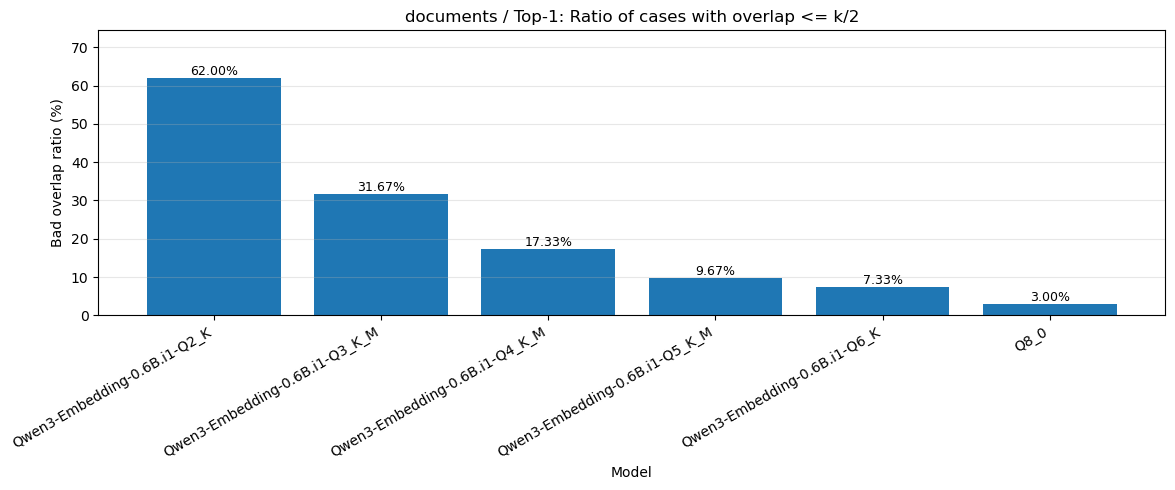

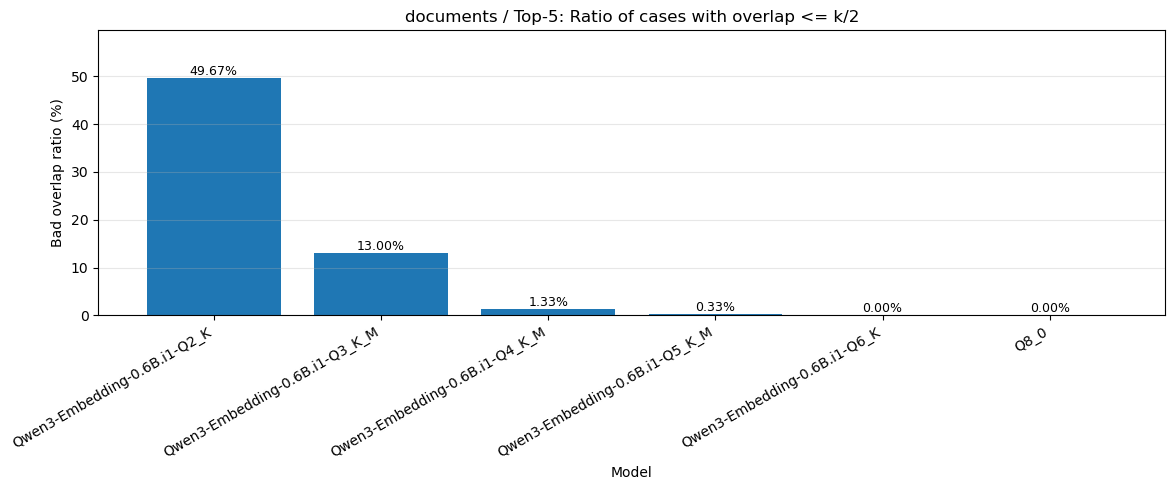

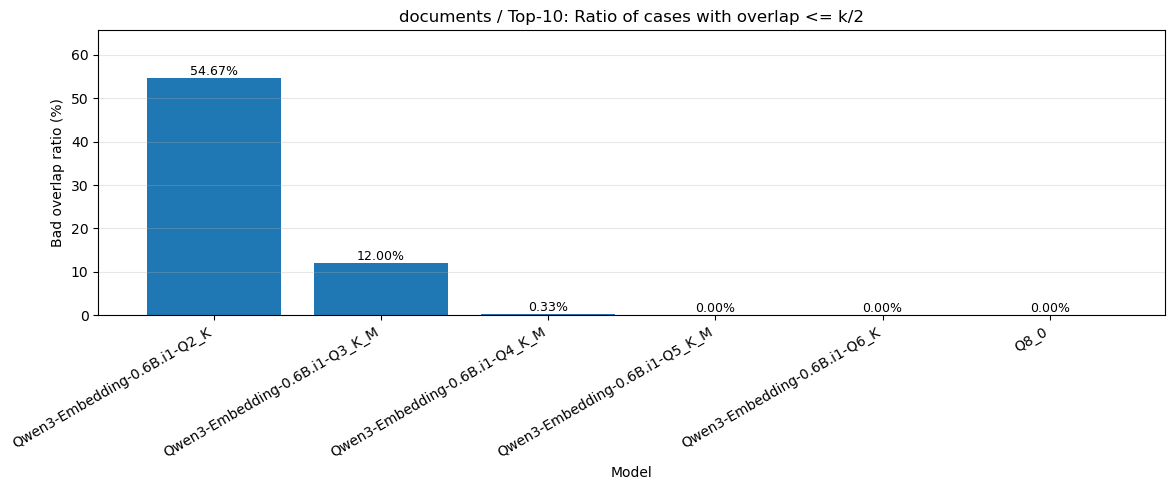

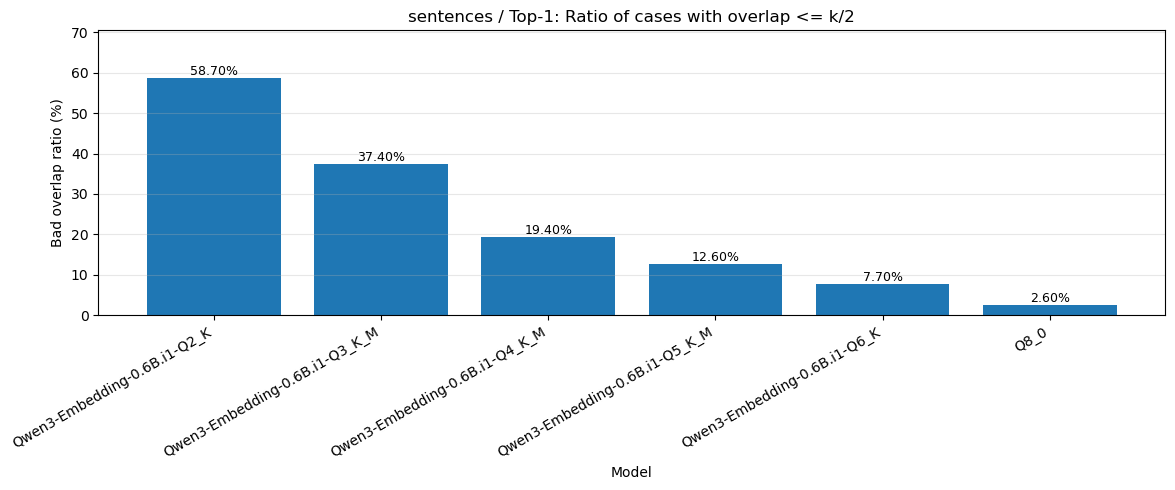

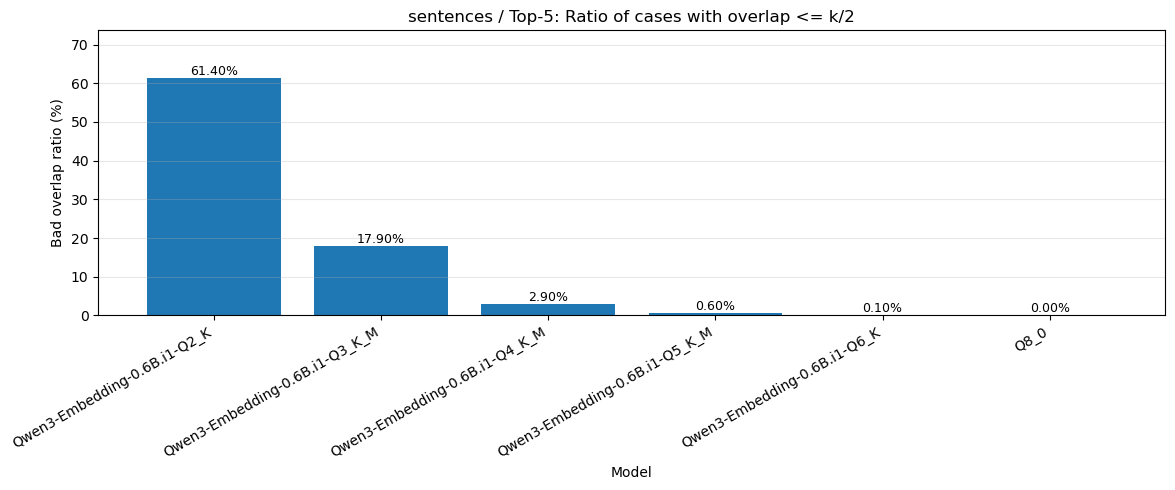

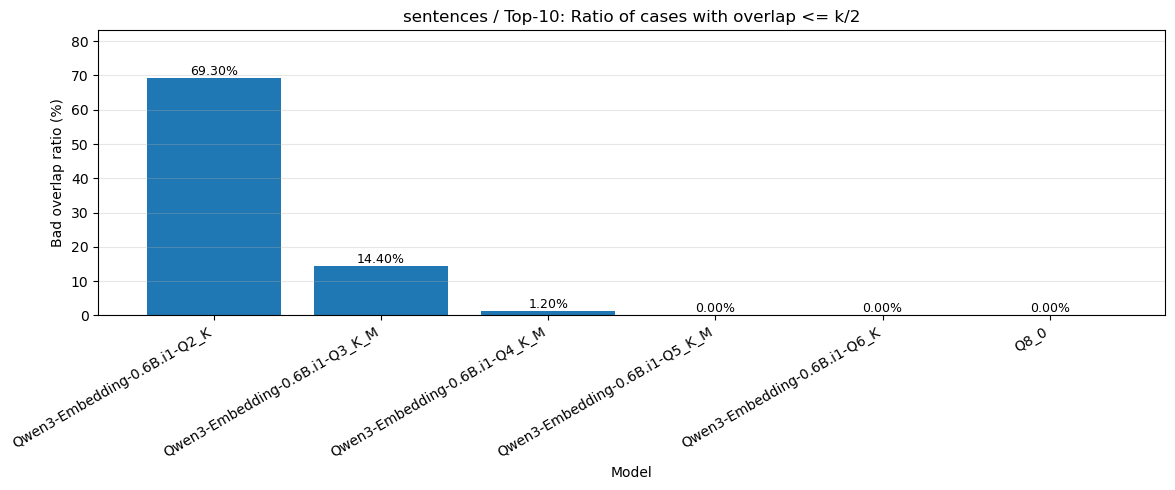

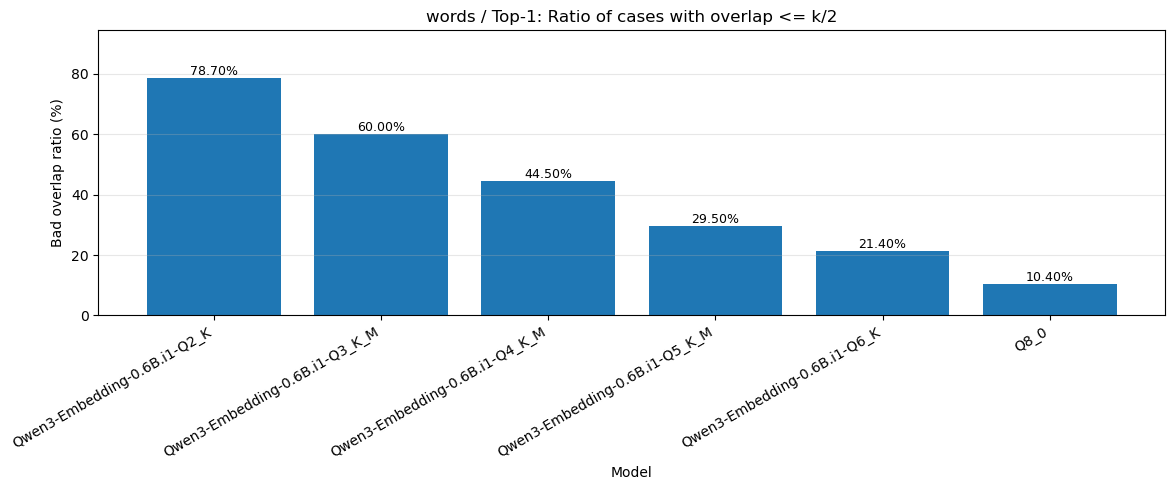

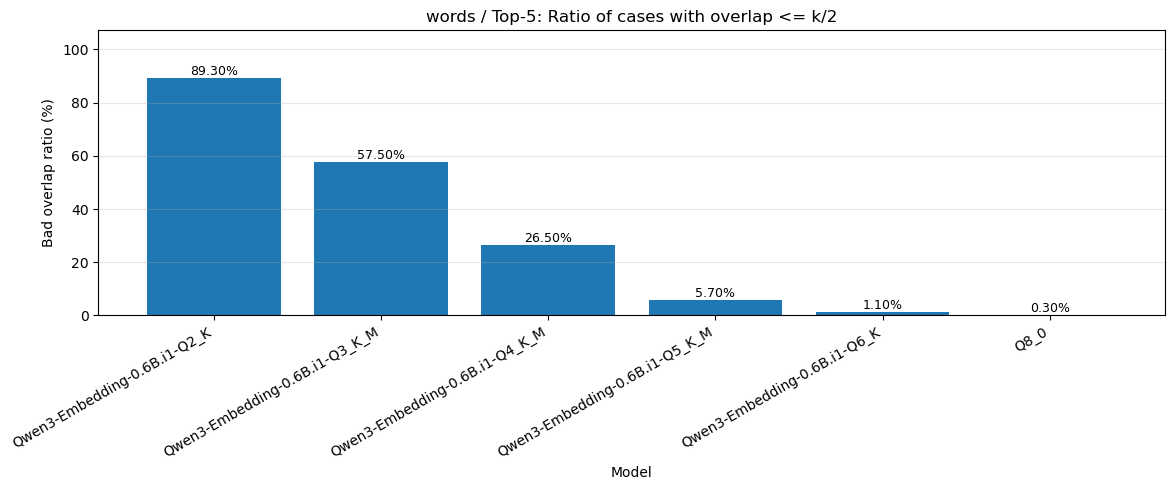

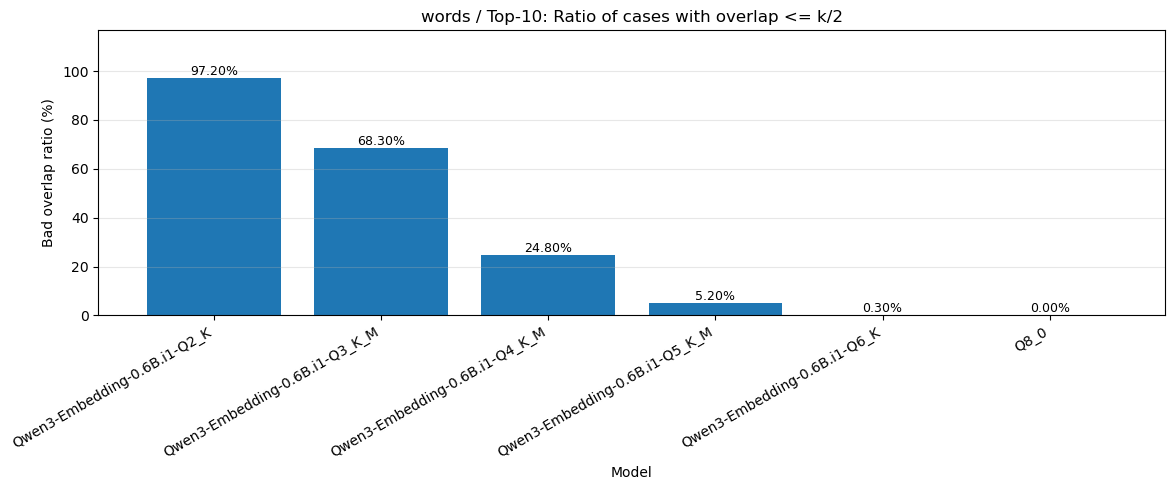

In [11]:
import matplotlib.pyplot as plt


def short_model_label(label: str) -> str:
    prefix = "Qwen3-Embedding-0.6B-"
    suffix = ".gguf"

    name = label

    if name.startswith(prefix):
        name = name[len(prefix):]

    if name.endswith(suffix):
        name = name[:-len(suffix)]

    return name


def plot_bad_overlap_ratio(group_name: str, k: int):
    target = bad_overlap_summary[
        (bad_overlap_summary["group"] == group_name)
        & (bad_overlap_summary["k"] == k)
    ].copy()

    if target.empty:
        print(f"[SKIP] group={group_name}, k={k}")
        return

    target = target.sort_values("bad_ratio", ascending=False)
    target["display_label"] = target["label"].map(short_model_label)

    fig = plt.figure(figsize=(12, 5))
    ax = plt.gca()

    bars = ax.bar(
        target["display_label"],
        target["bad_ratio"] * 100,
    )

    ax.set_title(f"{group_name} / Top-{k}: Ratio of cases with overlap <= k/2")
    ax.set_xlabel("Model")
    ax.set_ylabel("Bad overlap ratio (%)")
    ax.set_ylim(0, max(5, float((target["bad_ratio"] * 100).max()) * 1.2))
    ax.grid(axis="y", alpha=0.3)

    plt.xticks(rotation=30, ha="right")

    for bar, value in zip(bars, target["bad_ratio"] * 100):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{value:.2f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    plt.tight_layout()
    plt.show()


for group_name in sorted(ranking_detail_df["group"].unique()):
    for k in sorted(ranking_detail_df["k"].unique()):
        plot_bad_overlap_ratio(group_name, int(k))